In [1]:
# ============================================================================
# Environment
#   Python >= 3.10. Install dependencies with:
#       pip install -r requirements.txt
#   Run this notebook from the directory that contains it -- the one holding
#   survey_data/ -- so the relative ./survey_data/ paths below resolve.
# ============================================================================

import sys, os
print("Python:", sys.version.split()[0])
print("Working directory:", os.getcwd())
assert os.path.isdir("./survey_data"), (
    "./survey_data not found. Start Jupyter from the directory that contains "
    "this notebook and survey_data/, then re-run this cell."
)


# Generated figures are written here, not to the notebook's directory.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import json
import re
import os

new_combined_df= pd.read_excel("./survey_data/survey_results/survey_results.xlsx")
posts_df=pd.read_csv('./survey_data/moral_moments_data/135_posts.csv')
new_combined_df["j"] = np.where(new_combined_df["j"]=="YA", "Y", "N")
new_combined_df["j_2"] = np.where(new_combined_df["j_2"]=="YA", "Y", "N")
treatments=['controversy_certainty', 'controversy','certainty', 'control']

annotation_df=new_combined_df[(new_combined_df.treatment.isin(treatments))&(~new_combined_df.deliberation.isna())&(new_combined_df.is_ai_text==0)].reset_index().copy()

# mapping with explicit numeric prefix
conf_map = {
    1: '1 - uncertain',
    2: '2 - somewhat uncertain',
    3: '3 - somewhat certain',
    4: '4 - certain'
}

# apply mapping to c and c_2
annotation_df['c'] = annotation_df['c'].map(conf_map)
annotation_df['c_2'] = annotation_df['c_2'].map(conf_map)

Python: 3.10.13
Working directory: /Users/ziyuchen/AITA_data_profiling/controversy_certainty


In [2]:
import json
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# Columns produced by the new prompt
TREATMENT_COLS = [
    "disagreement_rate",
    "ingroup_certainty",
    "outgroup_certainty",
]
VALID_LABELS = {-1, 0, 1}


def parse_llm_response(raw_input):
    """Parses a single LLM string into a dictionary of treatment-engagement labels."""
    # Step 1: Strip "raw_response" prefix and quotes
    clean_str = re.sub(r'^raw_response\s*"?|"$', '', str(raw_input).strip())
    # Step 2: Remove markdown code blocks
    clean_str = re.sub(r"```json\n?|```", "", clean_str).strip()

    try:
        data = json.loads(clean_str)
    except (json.JSONDecodeError, TypeError):
        return {col: np.nan for col in TREATMENT_COLS} | {"rationale": ""}

    row_data = {}
    for col in TREATMENT_COLS:
        val = data.get(col)
        try:
            numeric_val = int(float(val))
            row_data[col] = numeric_val if numeric_val in VALID_LABELS else np.nan
        except (ValueError, TypeError):
            row_data[col] = np.nan

    row_data["rationale"] = data.get("rationale", "")
    return row_data


def process_results_to_df(results, annotation_df):
    """Converts a list of LLM strings into a structured, aligned DataFrame."""
    parsed_rows = [parse_llm_response(res) for res in results]
    analysis_df = pd.DataFrame(parsed_rows)

    temp_anno = annotation_df.reset_index(drop=True)
    temp_anal = analysis_df.reset_index(drop=True)

    n = min(len(temp_anno), len(temp_anal))
    return pd.concat([temp_anno.iloc[:n], temp_anal.iloc[:n]], axis=1)


def load_and_reprocess(filename, original_df):
    """Load results from JSONL and reprocess into DataFrame."""
    loaded_results = []
    with open(filename, "r") as f:
        for line in f:
            loaded_results.append(json.loads(line)["raw_response"])
    return process_results_to_df(loaded_results, original_df)


# Execute
final_df = load_and_reprocess("./survey_data/survey_results/deliberation_results.jsonl", annotation_df)

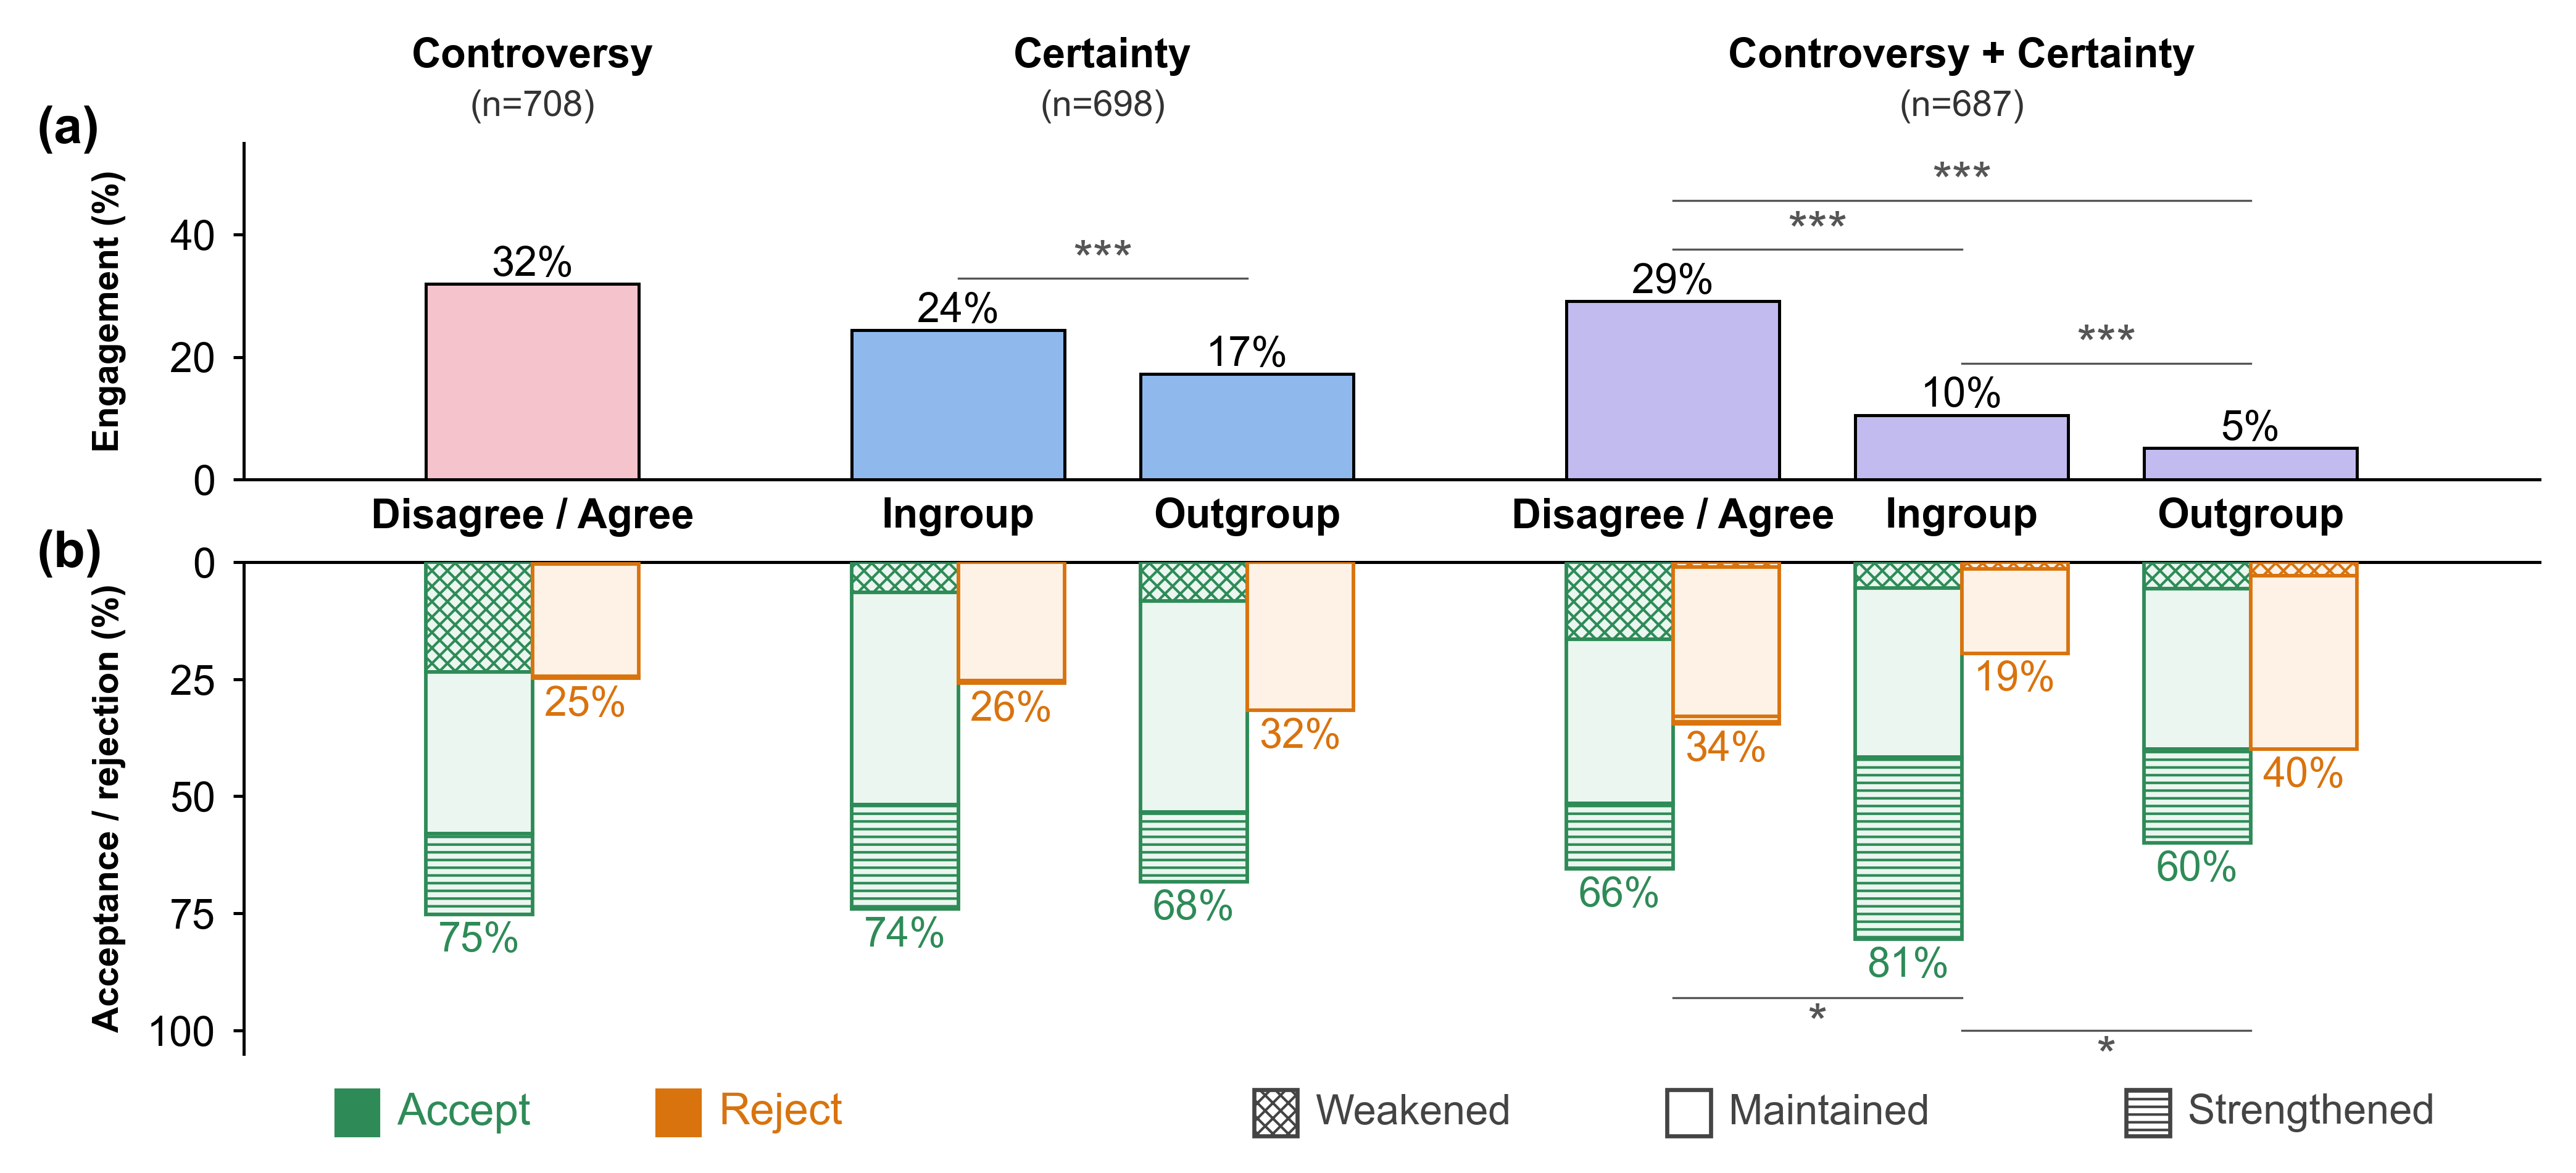

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import barnard_exact
from itertools import combinations


# =============================================================================
# Shared tokens
# =============================================================================

VARIABLE_SHORT = {
    "disagreement_rate":  "Disagree / Agree",
    "ingroup_certainty":  "Ingroup",
    "outgroup_certainty": "Outgroup",
}
VAR_ORDER = ["disagreement_rate", "ingroup_certainty", "outgroup_certainty"]

# Treatment palette (panel a bar colors)
PAL_CONTROL     = "#C8C8C8"
PAL_CERTAINTY   = "#8FB8ED"
PAL_CONTROVERSY = "#F4C3CB"
PAL_COMBINED    = "#C2BBF0"

COLOR_BAR_EDGE  = "black"   # edge for panel a bars

# Direction palette (panel b) - green / orange
COLOR_ACCEPT = "#2E8B57"   # green (edge + hatch)
COLOR_REJECT = "#D9730D"   # orange (edge + hatch)
COLOR_ACCEPT_FILL = "#EAF6EF"
COLOR_REJECT_FILL = "#FDF2E5"

# Outcome split (panel b)
OUTCOMES = ["weakened", "maintained", "strengthened"]
OUTCOME_LABELS = {
    "weakened":     "Weakened",
    "maintained":   "Maintained",
    "strengthened": "Strengthened",
}
OUTCOME_HATCH = {
    "weakened":     "xxxxxxxx",
    "maintained":   "",
    "strengthened": "--------",
}

COND_ORDER = ["controversy", "certainty", "controversy_certainty"]
COND_LABELS = {
    "controversy":           "Controversy",
    "certainty":             "Certainty",
    "controversy_certainty": "Controversy + Certainty",
}
COND_VARS = {
    "controversy":           ["disagreement_rate"],
    "certainty":             ["ingroup_certainty", "outgroup_certainty"],
    "controversy_certainty": ["disagreement_rate", "ingroup_certainty",
                              "outgroup_certainty"],
}
COND_COLORS = {
    "controversy":           PAL_CONTROVERSY,
    "certainty":             PAL_CERTAINTY,
    "controversy_certainty": PAL_COMBINED,
}


# =============================================================================
# Layout & typography constants (tune these to fix overlap)
# =============================================================================

# --- Font sizes ---
FS_DATA_LABEL      = 8
FS_N_LABEL         = 7
FS_TICK_LABEL      = 8
FS_CONDITION_LABEL = 8
FS_PANEL_LETTER    = 10
FS_YLABEL          = 7
FS_LEGEND          = 8.5
FS_LEGEND_OUTCOME  = 8
FS_BRACKET_STARS   = 10

# --- Text colors ---
COLOR_N_LABEL    = "#333333"
COLOR_YLABEL     = "black"
COLOR_LEGEND_DIM = "#444444"

# --- Panel a layout ---
PANEL_A_YLIM             = (0, 55)
PANEL_A_N_LABEL_Y        = 5
PANEL_A_DATA_LABEL_PAD   = 0.1
PANEL_A_BRACKET_BASE_PAD = 8
PANEL_A_BRACKET_STACK    = 8
PANEL_A_COND_LABEL_Y     = 1.2
PANEL_A_COND_N_Y         = 1.16   # n line, just under the condition title
PANEL_A_PANEL_LETTER_Y   = 1.0
PANEL_A_YLABEL_Y         = 1.02

# --- Panel b layout (per-condition split, two stacked bars, hanging down) ---
# YMAX is the largest magnitude shown downward. The data area runs from
# 0 (top, the shared bar baseline) to -YMAX (bottom).
PANEL_B_YMAX             = 105
PANEL_B_YTICKS           = (0, 25, 50, 75, 100)
PANEL_B_BRACKET_BASE_PAD = 12
PANEL_B_BRACKET_STACK    = 7
PANEL_B_DATA_LABEL_PAD   = 1.5
PANEL_B_PANEL_LETTER_Y   = 0.99
PANEL_B_YLABEL_Y         = 0.00
PANEL_B_LEGEND_Y_ROW     = -0.12   # single legend row, below the panel
PANEL_B_LEGEND_X_DIR     = 0.04    # direction group, flush left
PANEL_B_LEGEND_X_OUTCOME = 0.44    # outcome group, pushed right
PANEL_B_LEGEND_SWATCH_PT = 8.5     # swatch side, in points (kept square)
PANEL_B_LEGEND_GAP_PT    = 3.5     # swatch-to-text gap, in points

# --- Shared x-layout ---
BAR_WIDTH = 0.07          # engagement bar width (panel a)
INTER_GAP = 0.07
INTRA_GAP = 0.025
X_PAD     = 0.06

# --- Bracket appearance ---
BRACKET_LW          = 0.4
BRACKET_HEIGHT      = 0.5
COLOR_BRACKET       = "#555555"   # dark gray for lines and stars


# =============================================================================
# Small utilities
# =============================================================================

def p_to_stars(p):
    if pd.isna(p):
        return "n.s."
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."


def set_nature_style():
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 8,
        "legend.fontsize": 6,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.major.size": 2,
        "ytick.major.size": 2,
        "hatch.linewidth": 0.5,
        # hatch.color is deliberately left out here: matplotlib reads it when a
        # patch is created, and a value already set in this kernel would stick.
        # Panel b pins it per patch with plt.rc_context instead.
    })


def _add_bracket(ax, x1, x2, y, stars,
                 height=BRACKET_HEIGHT, lw=BRACKET_LW,
                 fontsize=FS_BRACKET_STARS):
    """Upward bracket (panel a): line above y, stars just above the line.

    The line-to-star gap is kept in data units, mirroring panel b, so the two
    panels show the same tight spacing despite their different axis scales.
    """
    line_y = y + height
    ax.plot([x1, x2], [line_y, line_y], color=COLOR_BRACKET, lw=lw)
    ax.text((x1 + x2) / 2, line_y - 1.3, stars,
            ha="center", va="bottom", fontsize=fontsize, color=COLOR_BRACKET)


def _add_bracket_down(ax, x1, x2, y, stars,
                      height=BRACKET_HEIGHT, lw=BRACKET_LW,
                      fontsize=FS_BRACKET_STARS):
    """Downward bracket (panel b): line below y, stars just below the line.

    y is already a negative data coordinate. The line-to-star gap is kept in
    data units, matching the original panel b spacing.
    """
    line_y = y - height
    ax.plot([x1, x2], [line_y, line_y], color=COLOR_BRACKET, lw=lw)
    ax.text((x1 + x2) / 2, line_y - 1.2, stars,
            ha="center", va="top", fontsize=fontsize, color=COLOR_BRACKET)


def _layout_x_positions(inter_gap=INTER_GAP):
    """Shared x-layout for panels a and b.

    Each condition's column is sized to its actual number of variables,
    so single-variable conditions are narrower than multi-variable ones.
    Bar width and intra-gap stay constant; only column width varies.
    """
    column_spans = np.array([
        len(COND_VARS[c]) * BAR_WIDTH + (len(COND_VARS[c]) - 1) * INTRA_GAP
        for c in COND_ORDER
    ])

    group_centers = np.zeros(len(COND_ORDER))
    for i in range(1, len(COND_ORDER)):
        group_centers[i] = (group_centers[i - 1]
                            + column_spans[i - 1] / 2
                            + inter_gap
                            + column_spans[i] / 2)
    return group_centers, column_spans, BAR_WIDTH, INTRA_GAP


# =============================================================================
# Statistical tests
# =============================================================================

def _prop_test(k1, n1, k2, n2):
    """Two-sided Barnard's exact test. Columns = groups (fixed totals n1, n2),
    rows = success / failure -- scipy treats the COLUMNS as the two groups, so
    this orientation is what makes n1 and n2 the fixed margins.

    Two-sided is the only defensible choice here: none of these comparisons has
    a direction predicted in advance. The earlier version read the direction off
    the observed difference and then tested only that tail, which is not a valid
    directional test -- choosing the tail after seeing the data roughly halves
    every p-value and inflates the false-positive rate.
    """
    if n1 == 0 or n2 == 0:
        return np.nan

    table = [[k1, k2],
             [n1 - k1, n2 - k2]]

    try:
        return barnard_exact(table, alternative="two-sided").pvalue
    except Exception:
        return np.nan


def _engagement_counts(df, cond, var, treatment_col):
    sub = df[df[treatment_col] == cond]
    n = len(sub)
    k = int((sub[var] != 0).sum())
    return k, n


def _acceptance_counts(df, cond, var, treatment_col):
    sub = df[df[treatment_col] == cond]
    engaged = sub[sub[var] != 0]
    n = len(engaged)
    k = int((engaged[var] == 1).sum())
    return k, n


def run_all_observation_tests(df, treatment_col="treatment"):
    """Compute pairwise tests for panels a and b. No multiple-comparison
    correction is applied; p_raw holds the unadjusted p-values."""
    # Panel a comparisons (engagement rate)
    rows_a = []
    cond = "certainty"
    for v1, v2 in combinations(COND_VARS[cond], 2):
        k1, n1 = _engagement_counts(df, cond, v1, treatment_col)
        k2, n2 = _engagement_counts(df, cond, v2, treatment_col)
        rows_a.append({
            "panel": "a", "pool": "single", "cond": cond,
            "comparison": f"{v1} vs {v2}",
            "p_unadj": _prop_test(k1, n1, k2, n2),
            "k1": k1, "n1": n1, "k2": k2, "n2": n2,
        })
    cond = "controversy_certainty"
    for v1, v2 in combinations(COND_VARS[cond], 2):
        k1, n1 = _engagement_counts(df, cond, v1, treatment_col)
        k2, n2 = _engagement_counts(df, cond, v2, treatment_col)
        rows_a.append({
            "panel": "a", "pool": "combined", "cond": cond,
            "comparison": f"{v1} vs {v2}",
            "p_unadj": _prop_test(k1, n1, k2, n2),
            "k1": k1, "n1": n1, "k2": k2, "n2": n2,
        })

    # Panel b comparisons (acceptance rate among engagers)
    rows_b = []
    for cond, pool_key in [("certainty", "single"),
                           ("controversy_certainty", "combined")]:
        for v1, v2 in combinations(COND_VARS[cond], 2):
            k1, n1 = _acceptance_counts(df, cond, v1, treatment_col)
            k2, n2 = _acceptance_counts(df, cond, v2, treatment_col)
            rows_b.append({
                "panel": "b", "pool": pool_key, "cond": cond,
                "comparison": f"{v1} vs {v2}",
                "p_unadj": _prop_test(k1, n1, k2, n2),
                "k1": k1, "n1": n1, "k2": k2, "n2": n2,
            })

    df_a = pd.DataFrame(rows_a)
    df_b = pd.DataFrame(rows_b)

    if not df_a.empty:
        df_a["p_raw"] = df_a["p_unadj"]
    if not df_b.empty:
        df_b["p_raw"] = df_b["p_unadj"]

    obs1a = (df_a[df_a["pool"] == "single"].reset_index(drop=True)
             if not df_a.empty else df_a)
    obs1b = (df_a[df_a["pool"] == "combined"].reset_index(drop=True)
             if not df_a.empty else df_a)
    obs3  = df_b.reset_index(drop=True)

    return {
        "obs1a_ingroup_vs_disagreement_single": obs1a,
        "obs1b_within_combined_pairwise":       obs1b,
        "obs3_acceptance_across_variables":     obs3,
    }


# =============================================================================
# Data helpers
# =============================================================================

def add_outcome_column(df, judgment_col="j", judgment_col_2="j_2",
                       conf_col="c", conf_col_2="c_2",
                       out_col="outcome"):
    """Add an outcome column with three values: weakened, maintained,
    strengthened.

    A row counts as weakened if the judgment changed, or if the judgment
    stayed the same but confidence went down. A row counts as strengthened
    if the judgment stayed the same and confidence went up. Otherwise the
    row counts as maintained.
    """
    df = df.copy()
    judgment_changed = df[judgment_col] != df[judgment_col_2]
    conf_down = df[conf_col_2] < df[conf_col]
    conf_up   = df[conf_col_2] > df[conf_col]

    outcome = np.full(len(df), "maintained", dtype=object)
    outcome[judgment_changed.values | (~judgment_changed.values & conf_down.values)] = "weakened"
    outcome[~judgment_changed.values & conf_up.values] = "strengthened"

    df[out_col] = outcome
    return df


def _cond_values(df, cond, variables, metric, treatment_col):
    sub = df[df[treatment_col] == cond]
    vals = []
    ns   = []
    for var in variables:
        if metric == "engagement":
            if len(sub) == 0:
                vals.append(np.nan); ns.append(0); continue
            vals.append((sub[var] != 0).mean() * 100)
            ns.append(len(sub))
        else:
            engaged = sub[sub[var] != 0]
            if len(engaged) == 0:
                vals.append(np.nan); ns.append(0); continue
            vals.append((engaged[var] == 1).mean() * 100)
            ns.append(len(engaged))
    return vals, ns


def _direction_outcome_from_subset(engaged, var, outcome_col="outcome"):
    """For one engaged subset and one variable, return the accept and reject
    rates plus the outcome split.

    Segment heights are expressed as % of engagers, so the accept and reject
    bars together account for 100% of engagers, and each bar's segments sum
    to that bar's direction rate.
    """
    n_eng = len(engaged)
    info = {"n_engaged": n_eng}
    for direction, key in [(1, "accept"), (-1, "reject")]:
        grp = engaged[engaged[var] == direction]
        n_d = len(grp)
        rate = (100 * n_d / n_eng) if n_eng > 0 else np.nan
        segments = {}
        for oc in OUTCOMES:
            cnt = int((grp[outcome_col] == oc).sum())
            segments[oc] = (100 * cnt / n_eng) if n_eng > 0 else np.nan
        info[key] = {"rate": rate, "n": n_d, "segments": segments}
    return info


# =============================================================================
# Panel a: engagement bars (unchanged)
# =============================================================================

def _panel_engagement_bars(ax, df, single_results, combined_results,
                           treatment_col, panel_letter, ylabel,
                           group_centers, column_spans,
                           bar_width, intra_gap):
    all_xs = []
    all_var_labels = []
    cond_ns = {}

    for c_idx, cond in enumerate(COND_ORDER):
        variables = COND_VARS[cond]
        n_vars = len(variables)
        vals, ns = _cond_values(df, cond, variables, "engagement",
                                treatment_col)

        xs = group_centers[c_idx] + (
            np.arange(n_vars) - (n_vars - 1) / 2
        ) * (bar_width + intra_gap)

        color = COND_COLORS[cond]
        ax.bar(xs, vals, bar_width,
               color=color, edgecolor=COLOR_BAR_EDGE, linewidth=0.6)

        for x, v in zip(xs, vals):
            if not np.isnan(v):
                ax.text(x, v + PANEL_A_DATA_LABEL_PAD, f"{v:.0f}%",
                        ha="center", va="bottom",
                        fontsize=FS_DATA_LABEL)

        # n is a property of the condition, not of the individual signal, so
        # it is printed once under the condition title rather than inside each
        # bar. Variables within a condition share a denominator; if that ever
        # stops holding, the title falls back to a range.
        cond_ns[cond] = sorted({int(n) for n in ns if not pd.isna(n)})

        all_xs.append(xs)
        all_var_labels.extend([VARIABLE_SHORT[v] for v in variables])

        if n_vars >= 2:
            pool_results = (combined_results
                            if cond == "controversy_certainty"
                            else single_results)
            if pool_results is not None and not pool_results.empty:
                pool_key = ("combined"
                            if cond == "controversy_certainty"
                            else "single")

                # Collect significant pairs with each pair's own bar height.
                sig = []
                for i in range(n_vars):
                    for j in range(i + 1, n_vars):
                        comp = f"{variables[i]} vs {variables[j]}"
                        if "pool" in pool_results.columns:
                            row = pool_results[
                                (pool_results["pool"] == pool_key) &
                                (pool_results["comparison"] == comp)
                            ]
                        else:
                            row = pool_results[
                                pool_results["comparison"] == comp
                            ]
                        if row.empty:
                            continue
                        p = row["p_raw"].iloc[0]
                        if pd.isna(p) or p >= 0.05:
                            continue
                        vi = 0 if np.isnan(vals[i]) else vals[i]
                        vj = 0 if np.isnan(vals[j]) else vals[j]
                        sig.append((max(vi, vj), i, j, p))

                # Lowest bars first, so the shortest comparison (e.g. ingroup
                # vs outgroup) sits nearest the bars and the stack grows
                # upward from there. On a tie, the narrower span (smaller
                # j - i) goes innermost. This keeps the y-limit small.
                sig.sort(key=lambda t: (t[0], t[2] - t[1]))
                running_top = None
                for pair_base, i, j, p in sig:
                    y = pair_base + PANEL_A_BRACKET_BASE_PAD
                    if running_top is not None:
                        y = max(y, running_top + PANEL_A_BRACKET_STACK)
                    _add_bracket(ax, xs[i], xs[j], y, p_to_stars(p))
                    running_top = y

    flat_xs = np.concatenate(all_xs)
    ax.set_xticks(flat_xs)
    ax.set_xticklabels(all_var_labels, fontsize=FS_TICK_LABEL,
                       fontweight="bold")
    # Names only: the tick marks themselves add nothing, and panel b already
    # drops them.
    ax.tick_params(axis="x", which="both", length=0)
    ax.set_xlim(group_centers[0] - column_spans[0] / 2 - X_PAD,
                group_centers[-1] + column_spans[-1] / 2 + X_PAD)
    ax.set_ylabel(ylabel, fontsize=FS_YLABEL, color=COLOR_YLABEL,
                  fontweight="bold")
    ax.set_ylim(*PANEL_A_YLIM)
    ax.spines[["top", "right"]].set_visible(False)

    from matplotlib.transforms import blended_transform_factory
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for c_idx, cond in enumerate(COND_ORDER):
        ax.text(group_centers[c_idx], PANEL_A_COND_LABEL_Y,
                COND_LABELS[cond],
                transform=trans,
                ha="center", va="bottom",
                fontsize=FS_CONDITION_LABEL, fontweight="bold")

        uniq = cond_ns.get(cond, [])
        if len(uniq) == 1:
            n_text = f"(n={uniq[0]})"
        elif uniq:
            n_text = f"(n={uniq[0]}-{uniq[-1]})"
        else:
            n_text = ""
        if n_text:
            ax.text(group_centers[c_idx], PANEL_A_COND_N_Y, n_text,
                    transform=trans,
                    ha="center", va="top",
                    fontsize=FS_N_LABEL, color=COLOR_N_LABEL)

    ax.text(-0.09, PANEL_A_PANEL_LETTER_Y, panel_letter,
            transform=ax.transAxes,
            fontsize=FS_PANEL_LETTER, fontweight="bold")


# =============================================================================
# Panel b: per-condition split, two stacked bars, hanging downward
# =============================================================================

def _draw_brackets_b(ax, cond, variables, info_list, acceptance_results, xs):
    """Cross-variable acceptance-rate brackets within a condition.

    Brackets sit below the deepest bar in the pair. Because the bars hang
    downward, "below" means a more negative y. The stars are printed upright.
    """
    n_vars = len(variables)
    if n_vars < 2 or acceptance_results is None or acceptance_results.empty:
        return
    pool_key = ("combined" if cond == "controversy_certainty" else "single")

    # Downward depth (positive magnitude) of each variable's deepest bar.
    depths = []
    for info in info_list:
        a = info["accept"]["rate"]
        r = info["reject"]["rate"]
        a = 0 if pd.isna(a) else a
        r = 0 if pd.isna(r) else r
        depths.append(max(a, r))

    # Collect significant pairs with each pair's own depth.
    sig = []
    for i in range(n_vars):
        for j in range(i + 1, n_vars):
            comp = f"{variables[i]} vs {variables[j]}"
            rsel = acceptance_results
            if "pool" in rsel.columns:
                row = rsel[(rsel["pool"] == pool_key) &
                           (rsel["comparison"] == comp)]
            else:
                row = rsel[rsel["comparison"] == comp]
            if row.empty:
                continue
            p = row["p_raw"].iloc[0]
            if pd.isna(p) or p >= 0.05:
                continue
            sig.append((max(depths[i], depths[j]), i, j, p))

    # Shallowest pair first, nearest the bars; the stack grows downward from
    # there. On a tie (e.g. when a deep bar caps several pairs), the narrower
    # span (smaller j - i, such as ingroup vs outgroup) goes innermost.
    sig.sort(key=lambda t: (t[0], t[2] - t[1]))
    running = None
    for pair_depth, i, j, p in sig:
        d = pair_depth + PANEL_B_BRACKET_BASE_PAD
        if running is not None:
            d = max(d, running + PANEL_B_BRACKET_STACK)
        _add_bracket_down(ax, xs[i], xs[j], -d, p_to_stars(p))
        running = d


def _draw_panel_b_legend(ax):
    """Single legend row below panel b, split into two groups.

    Left, flush with the panel's left edge: direction (Accept / Reject), solid
    color swatches. Right, pushed toward the panel's right edge and separated
    by a gap: outcome (Weakened / Maintained / Strengthened), neutral swatches
    with the outcome hatch.

    Swatch size is given in points and converted to axes fractions here so the
    swatches come out square. Panel b is far wider than it is tall, so one
    fraction used for both sides drew a thin sliver instead of a box.
    """
    fig_w_in, fig_h_in = ax.figure.get_size_inches()
    pos = ax.get_position()
    sw_x = (PANEL_B_LEGEND_SWATCH_PT / 72) / (pos.width * fig_w_in)
    sw_y = (PANEL_B_LEGEND_SWATCH_PT / 72) / (pos.height * fig_h_in)
    gap  = (PANEL_B_LEGEND_GAP_PT / 72) / (pos.width * fig_w_in)
    y    = PANEL_B_LEGEND_Y_ROW

    # Left group: direction.
    dir_layout = [("Accept", COLOR_ACCEPT, 0.0),
                  ("Reject", COLOR_REJECT, 0.14)]
    for label, color, dx in dir_layout:
        x = PANEL_B_LEGEND_X_DIR + dx
        rect = Rectangle(
            (x, y - sw_y / 2), sw_x, sw_y,
            transform=ax.transAxes, clip_on=False,
            facecolor=color, edgecolor=color, linewidth=0.5,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x + sw_x + gap, y, label,
                transform=ax.transAxes, ha="left", va="center",
                fontsize=FS_LEGEND, color=color)

    # Right group: outcome hatch on a neutral fill. The swatch stands for the
    # pattern only - it is direction-agnostic - so it carries the hatch in the
    # same dark grey as its edge.
    oc_layout = list(zip(OUTCOMES, [0.0, 0.18, 0.38]))
    for oc, dx in oc_layout:
        x = PANEL_B_LEGEND_X_OUTCOME + dx
        with plt.rc_context({"hatch.color": "#444444"}):
            rect = Rectangle(
                (x, y - sw_y / 2), sw_x, sw_y,
                transform=ax.transAxes, clip_on=False,
                facecolor="white", edgecolor="#444444", linewidth=0.8,
                hatch=OUTCOME_HATCH[oc] or None,
                zorder=5,
            )
        ax.add_patch(rect)
        ax.text(x + sw_x + gap, y, OUTCOME_LABELS[oc],
                transform=ax.transAxes, ha="left", va="center",
                fontsize=FS_LEGEND_OUTCOME, color=COLOR_LEGEND_DIM)


def _panel_b_split_stacked(ax, df, acceptance_results, treatment_col,
                           panel_letter, ylabel,
                           group_centers, column_spans,
                           bar_width, intra_gap, outcome_col="outcome"):
    all_xs = []

    half_w = bar_width / 2.0      # each accept/reject bar = half engagement bar
    offset = half_w / 2.0         # pair is flush, total width = engagement bar

    for c_idx, cond in enumerate(COND_ORDER):
        variables = COND_VARS[cond]
        n_vars = len(variables)
        sub = df[df[treatment_col] == cond]

        xs = group_centers[c_idx] + (
            np.arange(n_vars) - (n_vars - 1) / 2
        ) * (bar_width + intra_gap)

        info_list = []
        for x, var in zip(xs, variables):
            engaged = sub[sub[var] != 0]
            info = _direction_outcome_from_subset(engaged, var, outcome_col)
            info_list.append(info)

            for key, color, fill, xoff in [
                ("accept", COLOR_ACCEPT, COLOR_ACCEPT_FILL, -offset),
                ("reject", COLOR_REJECT, COLOR_REJECT_FILL, +offset),
            ]:
                bx = x + xoff
                bottom = 0.0
                for oc in OUTCOMES:
                    h = info[key]["segments"][oc]
                    if pd.isna(h) or h <= 0:
                        continue
                    # Bars hang downward from the shared 0-line, so each
                    # segment is drawn toward negative y. The fill is white;
                    # the direction color (green for accept, orange for reject)
                    # draws the outline and the outcome hatch over it, so a
                    # maintained segment is outline-only.
                    with plt.rc_context({"hatch.color": color}):
                        ax.bar(bx, -h, half_w, bottom=-bottom,
                               facecolor=fill, edgecolor=color, linewidth=0.7,
                               hatch=OUTCOME_HATCH[oc] or None, zorder=3)
                    bottom += h

                total = info[key]["rate"]
                if not pd.isna(total):
                    # Label sits just past the end of the downward bar and is
                    # printed upright as a positive percentage.
                    ax.text(bx, -total - PANEL_B_DATA_LABEL_PAD,
                            f"{total:.0f}%",
                            ha="center", va="top",
                            fontsize=FS_DATA_LABEL, color=color)

        all_xs.append(xs)
        _draw_brackets_b(ax, cond, variables, info_list,
                         acceptance_results, xs)

    flat_xs = np.concatenate(all_xs)
    # Panel b shares panel a's x-axis names, so it carries no x labels.
    ax.set_xticks(flat_xs)
    ax.set_xticklabels([])
    ax.tick_params(axis="x", which="both", length=0)
    ax.set_xlim(group_centers[0] - column_spans[0] / 2 - X_PAD,
                group_centers[-1] + column_spans[-1] / 2 + X_PAD)
    ax.set_ylabel(ylabel, fontsize=FS_YLABEL, color=COLOR_YLABEL,
                  fontweight="bold")

    # y-axis runs 0 at the top down to -YMAX at the bottom. Tick numbers are
    # placed at negative positions but labelled with upright positive values.
    ax.set_ylim(-PANEL_B_YMAX, 0)
    yt = list(PANEL_B_YTICKS)
    ax.set_yticks([-t for t in yt])
    ax.set_yticklabels([str(t) for t in yt])

    # The shared 0-line is the top spine; bars hang from it. Keep the top and
    # left spines, drop the bottom and right.
    ax.spines[["bottom", "right"]].set_visible(False)
    ax.spines["top"].set_visible(True)

    ax.text(-0.09, PANEL_B_PANEL_LETTER_Y, panel_letter,
            transform=ax.transAxes,
            fontsize=FS_PANEL_LETTER, fontweight="bold")

    _draw_panel_b_legend(ax)


# =============================================================================
# Human-readable summary for paper writing
# =============================================================================

def print_observation_summary(df, observation_results,
                              treatment_col="treatment",
                              outcome_col="outcome"):
    obs1a = observation_results["obs1a_ingroup_vs_disagreement_single"]
    obs1b = observation_results["obs1b_within_combined_pairwise"]
    obs3  = observation_results["obs3_acceptance_across_variables"]

    def _fmt_p(p):
        if pd.isna(p):
            return "p=NA"
        if p < 0.001:
            return "p<0.001"
        return f"p={p}"

    def _tests_for(results_df, pool_key):
        if results_df is None or results_df.empty:
            return []
        if "pool" in results_df.columns:
            sub = results_df[results_df["pool"] == pool_key]
        else:
            sub = results_df
        return sub.to_dict("records")

    print("\n" + "=" * 70)
    print("PANEL A  - Engagement rate (% of participants referencing variable)")
    print("=" * 70)

    for cond in COND_ORDER:
        variables = COND_VARS[cond]
        sub = df[df[treatment_col] == cond]
        n_total = len(sub)
        print(f"\n[{COND_LABELS[cond]}]  n = {n_total}")
        for var in variables:
            k = int((sub[var] != 0).sum())
            rate = 100 * k / n_total if n_total > 0 else float("nan")
            print(f"  {VARIABLE_SHORT[var]:<10}  "
                  f"{rate:5.1f}%   ({k}/{n_total})")

        if len(variables) >= 2:
            pool_key = ("combined"
                        if cond == "controversy_certainty" else "single")
            tests = _tests_for(
                obs1b if cond == "controversy_certainty" else obs1a,
                pool_key,
            )
            if tests:
                print("  Pairwise tests (Barnard two-sided):")
                for t in tests:
                    print(f"    {t['comparison']:<55}  "
                          f"p_raw={t['p_unadj']}   "
                          f"{_fmt_p(t['p_raw'])}")

    print("\n" + "=" * 70)
    print("PANEL B  - Among engagers: acceptance / rejection + outcome split")
    print("=" * 70)

    for cond in COND_ORDER:
        variables = COND_VARS[cond]
        sub = df[df[treatment_col] == cond]
        print(f"\n[{COND_LABELS[cond]}]")
        for var in variables:
            engaged = sub[sub[var] != 0]
            n_eng = len(engaged)
            if n_eng == 0:
                print(f"  {VARIABLE_SHORT[var]:<10}  (no engagers)")
                continue
            n_acc = int((engaged[var] ==  1).sum())
            n_rej = int((engaged[var] == -1).sum())
            r_acc = 100 * n_acc / n_eng
            r_rej = 100 * n_rej / n_eng
            print(f"  {VARIABLE_SHORT[var]:<10}  n_engaged = {n_eng}")
            print(f"    Accept: {r_acc:5.1f}% ({n_acc}/{n_eng})")
            for oc in OUTCOMES:
                grp = engaged[engaged[var] == 1]
                if len(grp) > 0:
                    cnt = int((grp[outcome_col] == oc).sum())
                    rate = 100 * cnt / len(grp)
                    print(f"        {oc:<14} {rate:5.1f}%  ({cnt}/{len(grp)})")
            print(f"    Reject: {r_rej:5.1f}% ({n_rej}/{n_eng})")
            for oc in OUTCOMES:
                grp = engaged[engaged[var] == -1]
                if len(grp) > 0:
                    cnt = int((grp[outcome_col] == oc).sum())
                    rate = 100 * cnt / len(grp)
                    print(f"        {oc:<14} {rate:5.1f}%  ({cnt}/{len(grp)})")

        if len(variables) >= 2:
            pool_key = ("combined"
                        if cond == "controversy_certainty" else "single")
            tests = _tests_for(obs3, pool_key)
            if tests:
                print("  Pairwise tests on acceptance rate "
                      "(Barnard two-sided):")
                for t in tests:
                    print(f"    {t['comparison']:<55}  "
                          f"p_raw={t['p_unadj']}   "
                          f"{_fmt_p(t['p_raw'])}")

    print("\n" + "=" * 70 + "\n")


# =============================================================================
# Public driver
# =============================================================================

def make_observation_figure(df, observation_results,
                            treatment_col="treatment",
                            save_path=None):
    set_nature_style()

    obs1a = observation_results["obs1a_ingroup_vs_disagreement_single"]
    obs1b = observation_results["obs1b_within_combined_pairwise"]
    obs3  = observation_results["obs3_acceptance_across_variables"]

    group_centers, column_spans, bar_width, intra_gap = _layout_x_positions()

    # Top / bottom: panel a on top, panel b on bottom. The two panels meet at
    # the shared 0-line; the x-axis names sit under panel a only.
    fig = plt.figure(figsize=(8, 3), dpi=600)
    gs = fig.add_gridspec(2, 1, height_ratios=[1.3, 1.9], hspace=0.2)
    axes = [fig.add_subplot(gs[0]), fig.add_subplot(gs[1])]

    _panel_engagement_bars(
        axes[0], df,
        single_results=obs1a, combined_results=obs1b,
        treatment_col=treatment_col,
        panel_letter="(a)",
        ylabel="Engagement (%)",
        group_centers=group_centers, column_spans=column_spans,
        bar_width=bar_width, intra_gap=intra_gap,
    )

    _panel_b_split_stacked(
        axes[1], df,
        acceptance_results=obs3,
        treatment_col=treatment_col,
        panel_letter="(b)",
        ylabel="Acceptance / rejection (%)",
        group_centers=group_centers, column_spans=column_spans,
        bar_width=bar_width, intra_gap=intra_gap,
    )
    fig.align_ylabels(axes)

    fig.subplots_adjust(top=0.94, bottom=0.12)
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")
        plt.savefig(save_path.replace(".pdf", ".png"), dpi=600,
                    bbox_inches="tight")
    plt.show()


# =============================================================================
# Run
# =============================================================================

if __name__ == "__main__":
    df_with_outcome = add_outcome_column(final_df)

    observation_results = run_all_observation_tests(df_with_outcome)

    # print_observation_summary(df_with_outcome, observation_results)

    make_observation_figure(df_with_outcome, observation_results,
                            save_path=os.path.join(FIG_DIR, "fig4_deliberation_observations.pdf"))